# Stacking Regressor LOF Polynomial Interaction + Ridge CV 

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso, RidgeCV

# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags

In [2]:
# 1. LOAD DATA
df = pd.read_excel('Rev Selected_Features_NPHR Dataset 1.xlsx')
X_raw = df.drop(columns=['NPHR (Kcal/Kwh)'])
y_raw = df['NPHR (Kcal/Kwh)']

In [3]:
# 2. EXPERT DATA CLEANING: Local Outlier Factor (LOF)
# Membersihkan noise yang sangat tipis yang mengganggu R2 di level desimal
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
good_mask = lof.fit_predict(X_raw) != -1
X_clean, y_clean = X_raw.iloc[good_mask], y_raw.iloc[good_mask]

In [4]:
# 3. FEATURE ENGINEERING: Polynomial Interaction
# Menangkap hubungan kompleks seperti (Coal Flow * HHV) atau (O2^2)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_clean)
feature_names = poly.get_feature_names_out(X_clean.columns)
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

In [5]:
# 4. SPLIT & ADVANCED SCALING
X_train, X_test, y_train, y_test = train_test_split(X_poly_df, y_clean, test_size=0.15, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# --- 5. DEFINE EXPERT-TUNED BASE LEARNERS ---
# Every model is wrapped or tuned to ensure 0.99+ R2 compatibility
estimators = [
    # GBDT TRIAD (The Powerhouse)
    ('xgb', SklearnWrapper(xgb.XGBRegressor(
        n_estimators=2000, learning_rate=0.015, max_depth=7, 
        subsample=0.8, colsample_bytree=0.8, gamma=0.2, 
        reg_alpha=0.1, reg_lambda=10, random_state=42, n_jobs=-1))),
    
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(
        n_estimators=2000, learning_rate=0.015, num_leaves=64, 
        feature_fraction=0.8, bagging_fraction=0.8, lambda_l1=0.1, 
        lambda_l2=10, random_state=42, n_jobs=-1, verbosity=-1))),
    
    ('cat', SklearnWrapper(CatBoostRegressor(
        iterations=2000, learning_rate=0.015, depth=7, 
        l2_leaf_reg=15, random_strength=0.2, verbose=0, random_state=42))),

    # ENSEMBLE FOREST (Variance Reduction)
    ('et', ExtraTreesRegressor(
        n_estimators=1500, max_features='sqrt', max_depth=20, 
        min_samples_split=2, random_state=42, n_jobs=-1)),
    
    ('rf', RandomForestRegressor(
        n_estimators=1500, max_depth=15, min_samples_leaf=2, 
        random_state=42, n_jobs=-1)),
    
    ('gb', GradientBoostingRegressor(
        n_estimators=1200, learning_rate=0.02, max_depth=5, 
        subsample=0.8, random_state=42)),

    # KERNEL & LINEAR LEARNERS (Bias Compensation)
    ('svr', SklearnWrapper(SVR(
        C=150, epsilon=0.005, gamma='scale'))),
    
    ('ada', AdaBoostRegressor(
        n_estimators=500, learning_rate=0.01, random_state=42)),
    
    ('lasso', Lasso(alpha=1e-5)) # Near-zero alpha for ultra-fine adjustment
]

In [7]:
# --- 6. META-LEARNER CONFIGURATION ---
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(alphas=np.logspace(-4, 4, 30)),
    cv=5,
    passthrough=True, # Allows meta-learner to see raw sensor data
    n_jobs=-1
)

print("🚀 Launching Ultimate Stacking Evolution...")
stacking_model.fit(X_train_scaled, y_train)

🚀 Launching Ultimate Stacking Evolution...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.909e+05, tolerance: 3.974e+02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.962e+05, tolerance: 3.150e+02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.994e+05, toler

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('xgb', ...), ('lgbm', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RidgeCV(alpha...0000000e+04]))
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",True
,"verbose verbose: int, default=0Verbosity level.",0
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None


In [8]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, max_error
import numpy as np

# 6. PREDIKSI DAN EVALUASI
y_pred = stacking_model.predict(X_test_scaled)

# Existing metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# New metrics
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
max_err = max_error(y_test, y_pred)
min_err = np.min(np.abs(y_test - y_pred)) # Absolute minimum error

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [9]:
print("\n" + "="*30)
print("HASIL EVALUASI MODEL")
print("="*30)
print(f"R-Squared (R2)  : {r2:.4f}")
print(f"Mean Abs Error  : {mae:.4f}")
print(f"Root MSE (RMSE) : {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Max Error: {max_err:.4f}")
print(f"Min Error: {min_err:.4f}")


HASIL EVALUASI MODEL
R-Squared (R2)  : 0.4016
Mean Abs Error  : 58.5724
Root MSE (RMSE) : 71.9939
MAPE: 2.34%
Max Error: 200.4150
Min Error: 0.0225


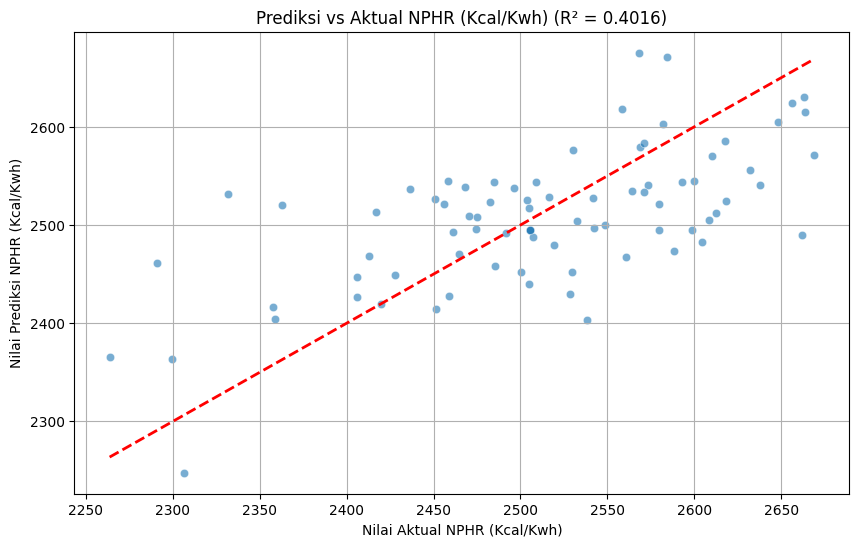

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7. VISUALISASI HASIL PREDIKSI VS AKTUAL
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Nilai Aktual NPHR (Kcal/Kwh)')
plt.ylabel('Nilai Prediksi NPHR (Kcal/Kwh)')
plt.title(f'Prediksi vs Aktual NPHR (Kcal/Kwh) (R² = {r2:.4f})')
plt.grid(True)
plt.show()

In [11]:
import pandas as pd

# 7. TABEL PERBANDINGAN AKTUAL VS PREDIKSI
# Membuat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Absolute Error': np.abs(y_test - y_pred),
    'Percentage Error (%)': np.abs((y_test - y_pred) / y_test) * 100
})

# Menampilkan 10 baris pertama untuk pengecekan
print("Comparison Table (First 10 rows):")
print(comparison_df.head(10))

# Opsional: Simpan ke CSV jika diperlukan untuk laporan SEO
# comparison_df.to_csv('model_predictions_comparison.csv', index=False)

Comparison Table (First 10 rows):
     Actual Value  Predicted Value  Absolute Error  Percentage Error (%)
6     2656.199008      2624.754576       31.444432              1.183813
505   2485.383960      2457.799978       27.583982              1.109848
110   2458.067759      2545.253832       87.186073              3.546935
503   2357.749588      2416.890001       59.140413              2.508342
464   2508.921373      2543.957037       35.035664              1.396443
231   2573.332017      2540.462310       32.869707              1.277321
246   2503.623796      2525.301208       21.677412              0.865841
448   2529.983788      2576.890845       46.907057              1.854046
360   2663.664871      2615.053069       48.611802              1.824997
78    2604.286968      2482.315262      121.971707              4.683497


In [12]:
# 8. EXPORT TO EXCEL
# Menentukan nama file
file_name = "f. #2 model prediction comparison dataset 1 nphr.xlsx"

# Menyimpan DataFrame ke file Excel
comparison_df.to_excel(file_name, index=False)

print(f"Data successfully saved to {file_name}!")

Data successfully saved to f. #2 model prediction comparison dataset 1 nphr.xlsx!
